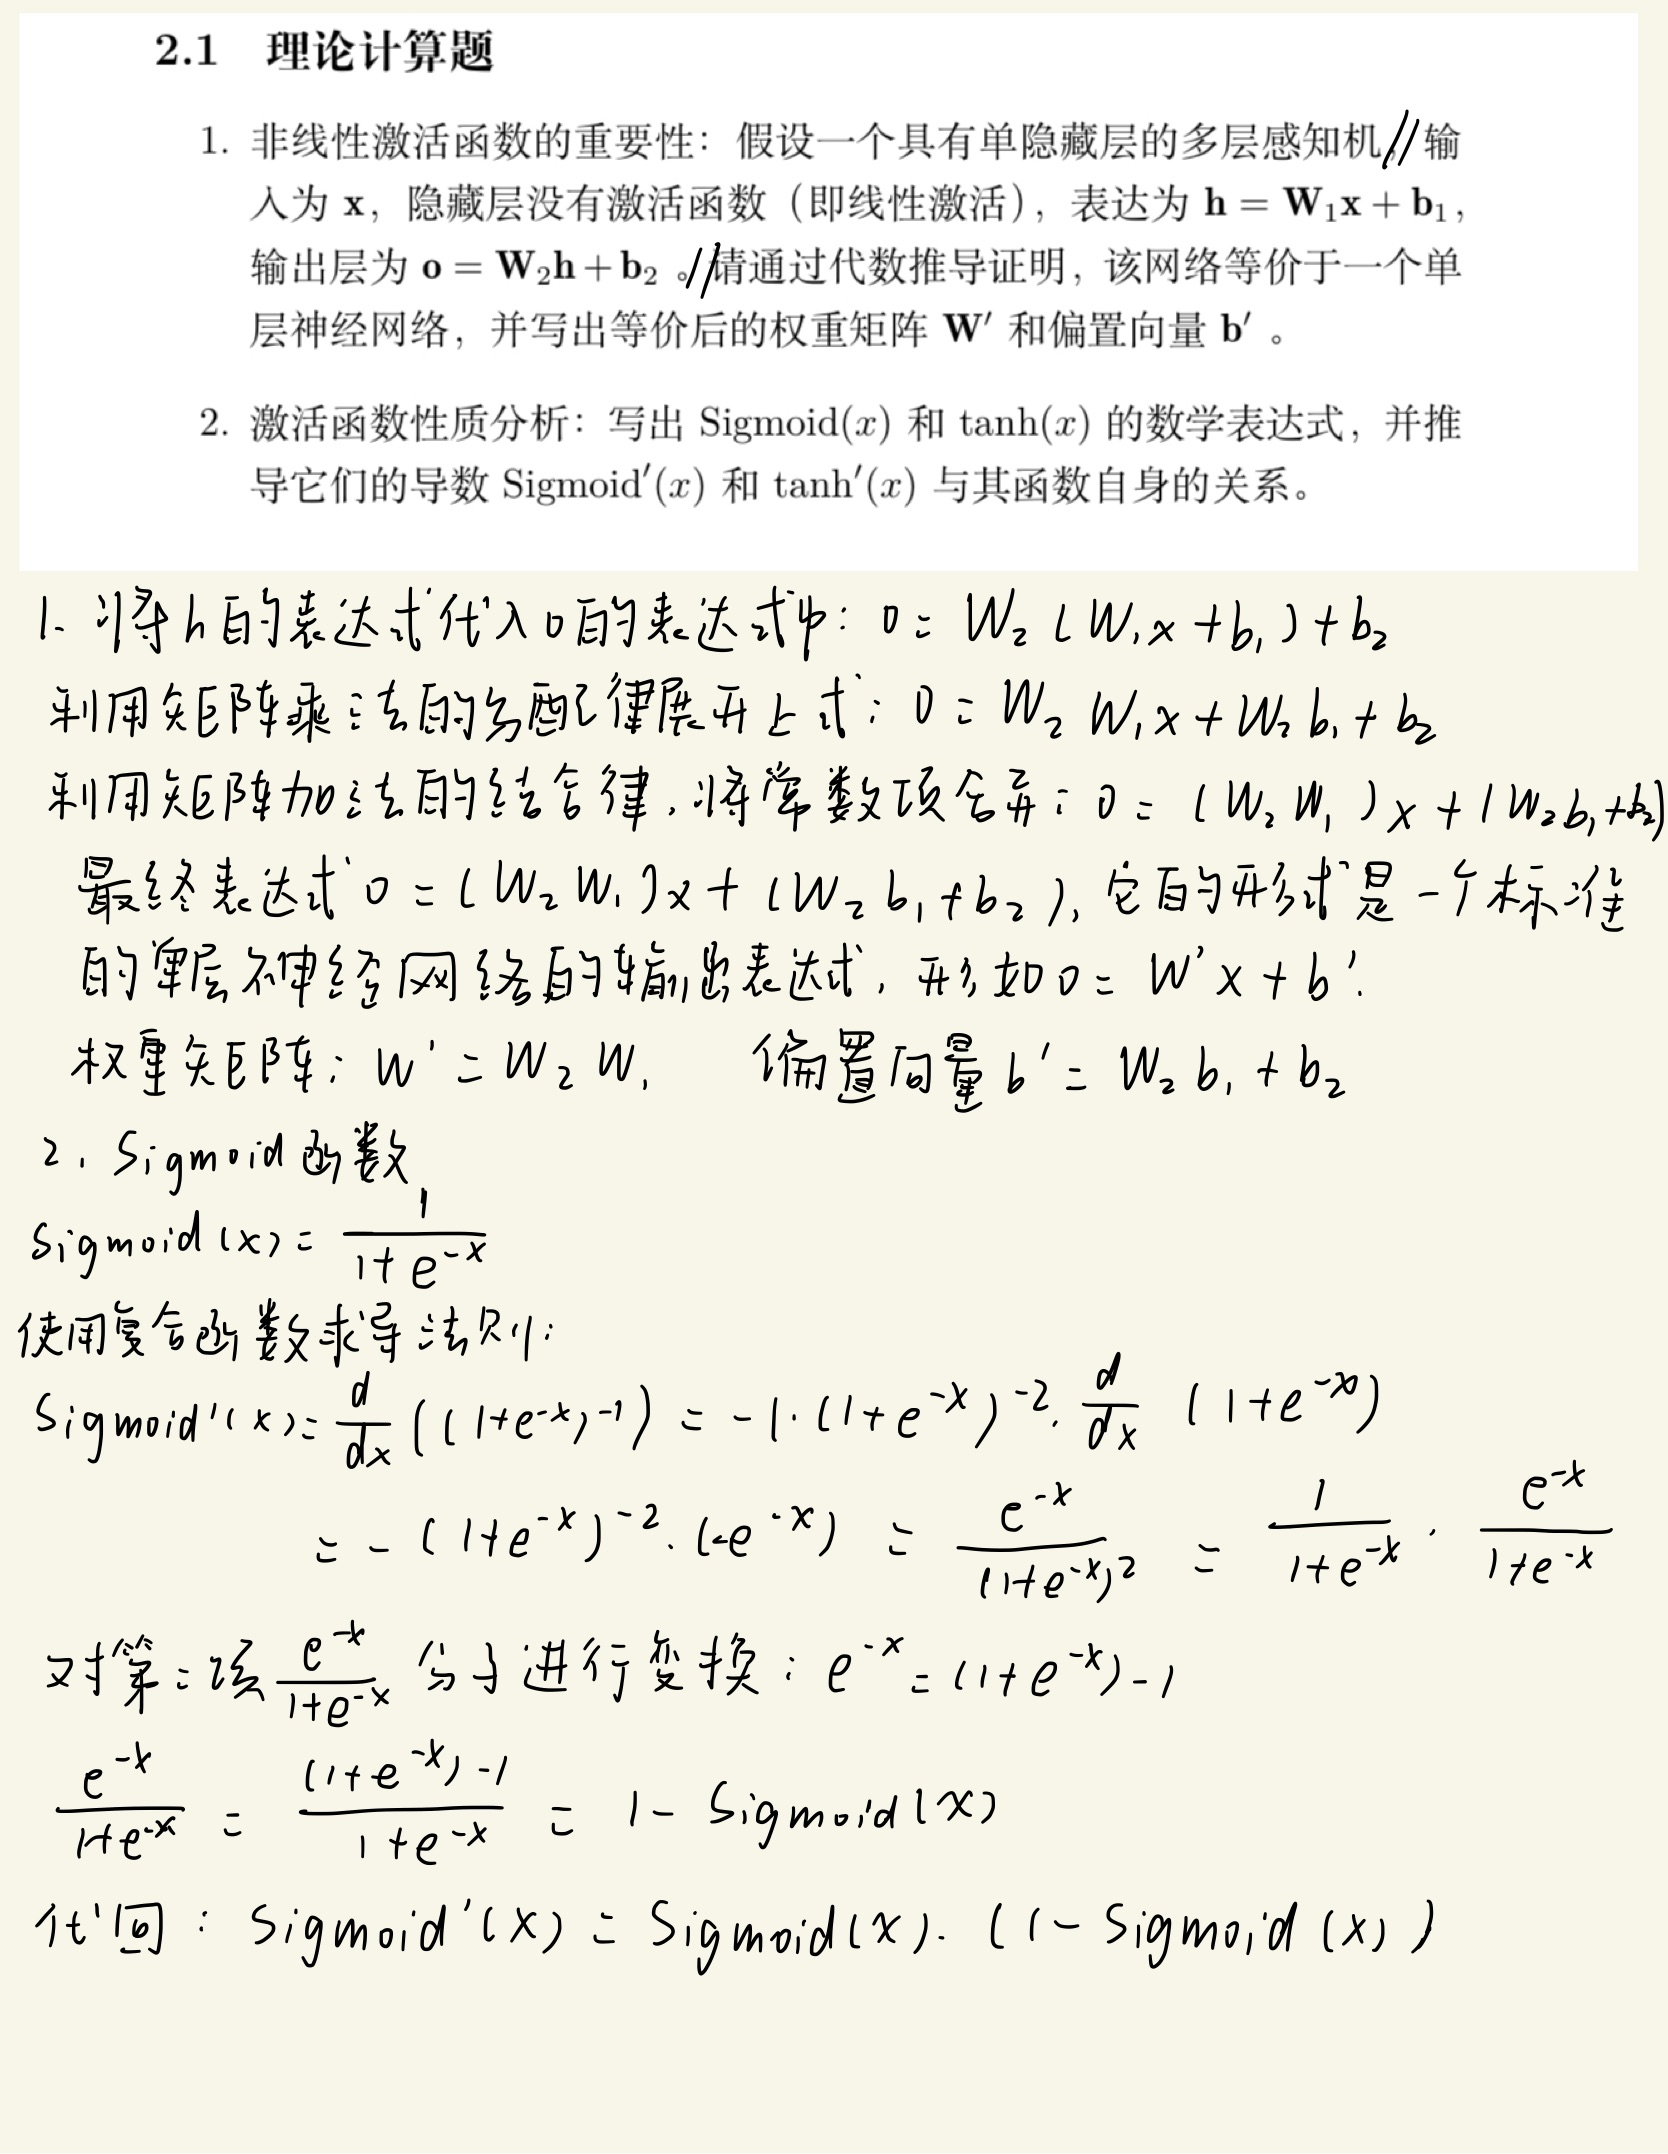

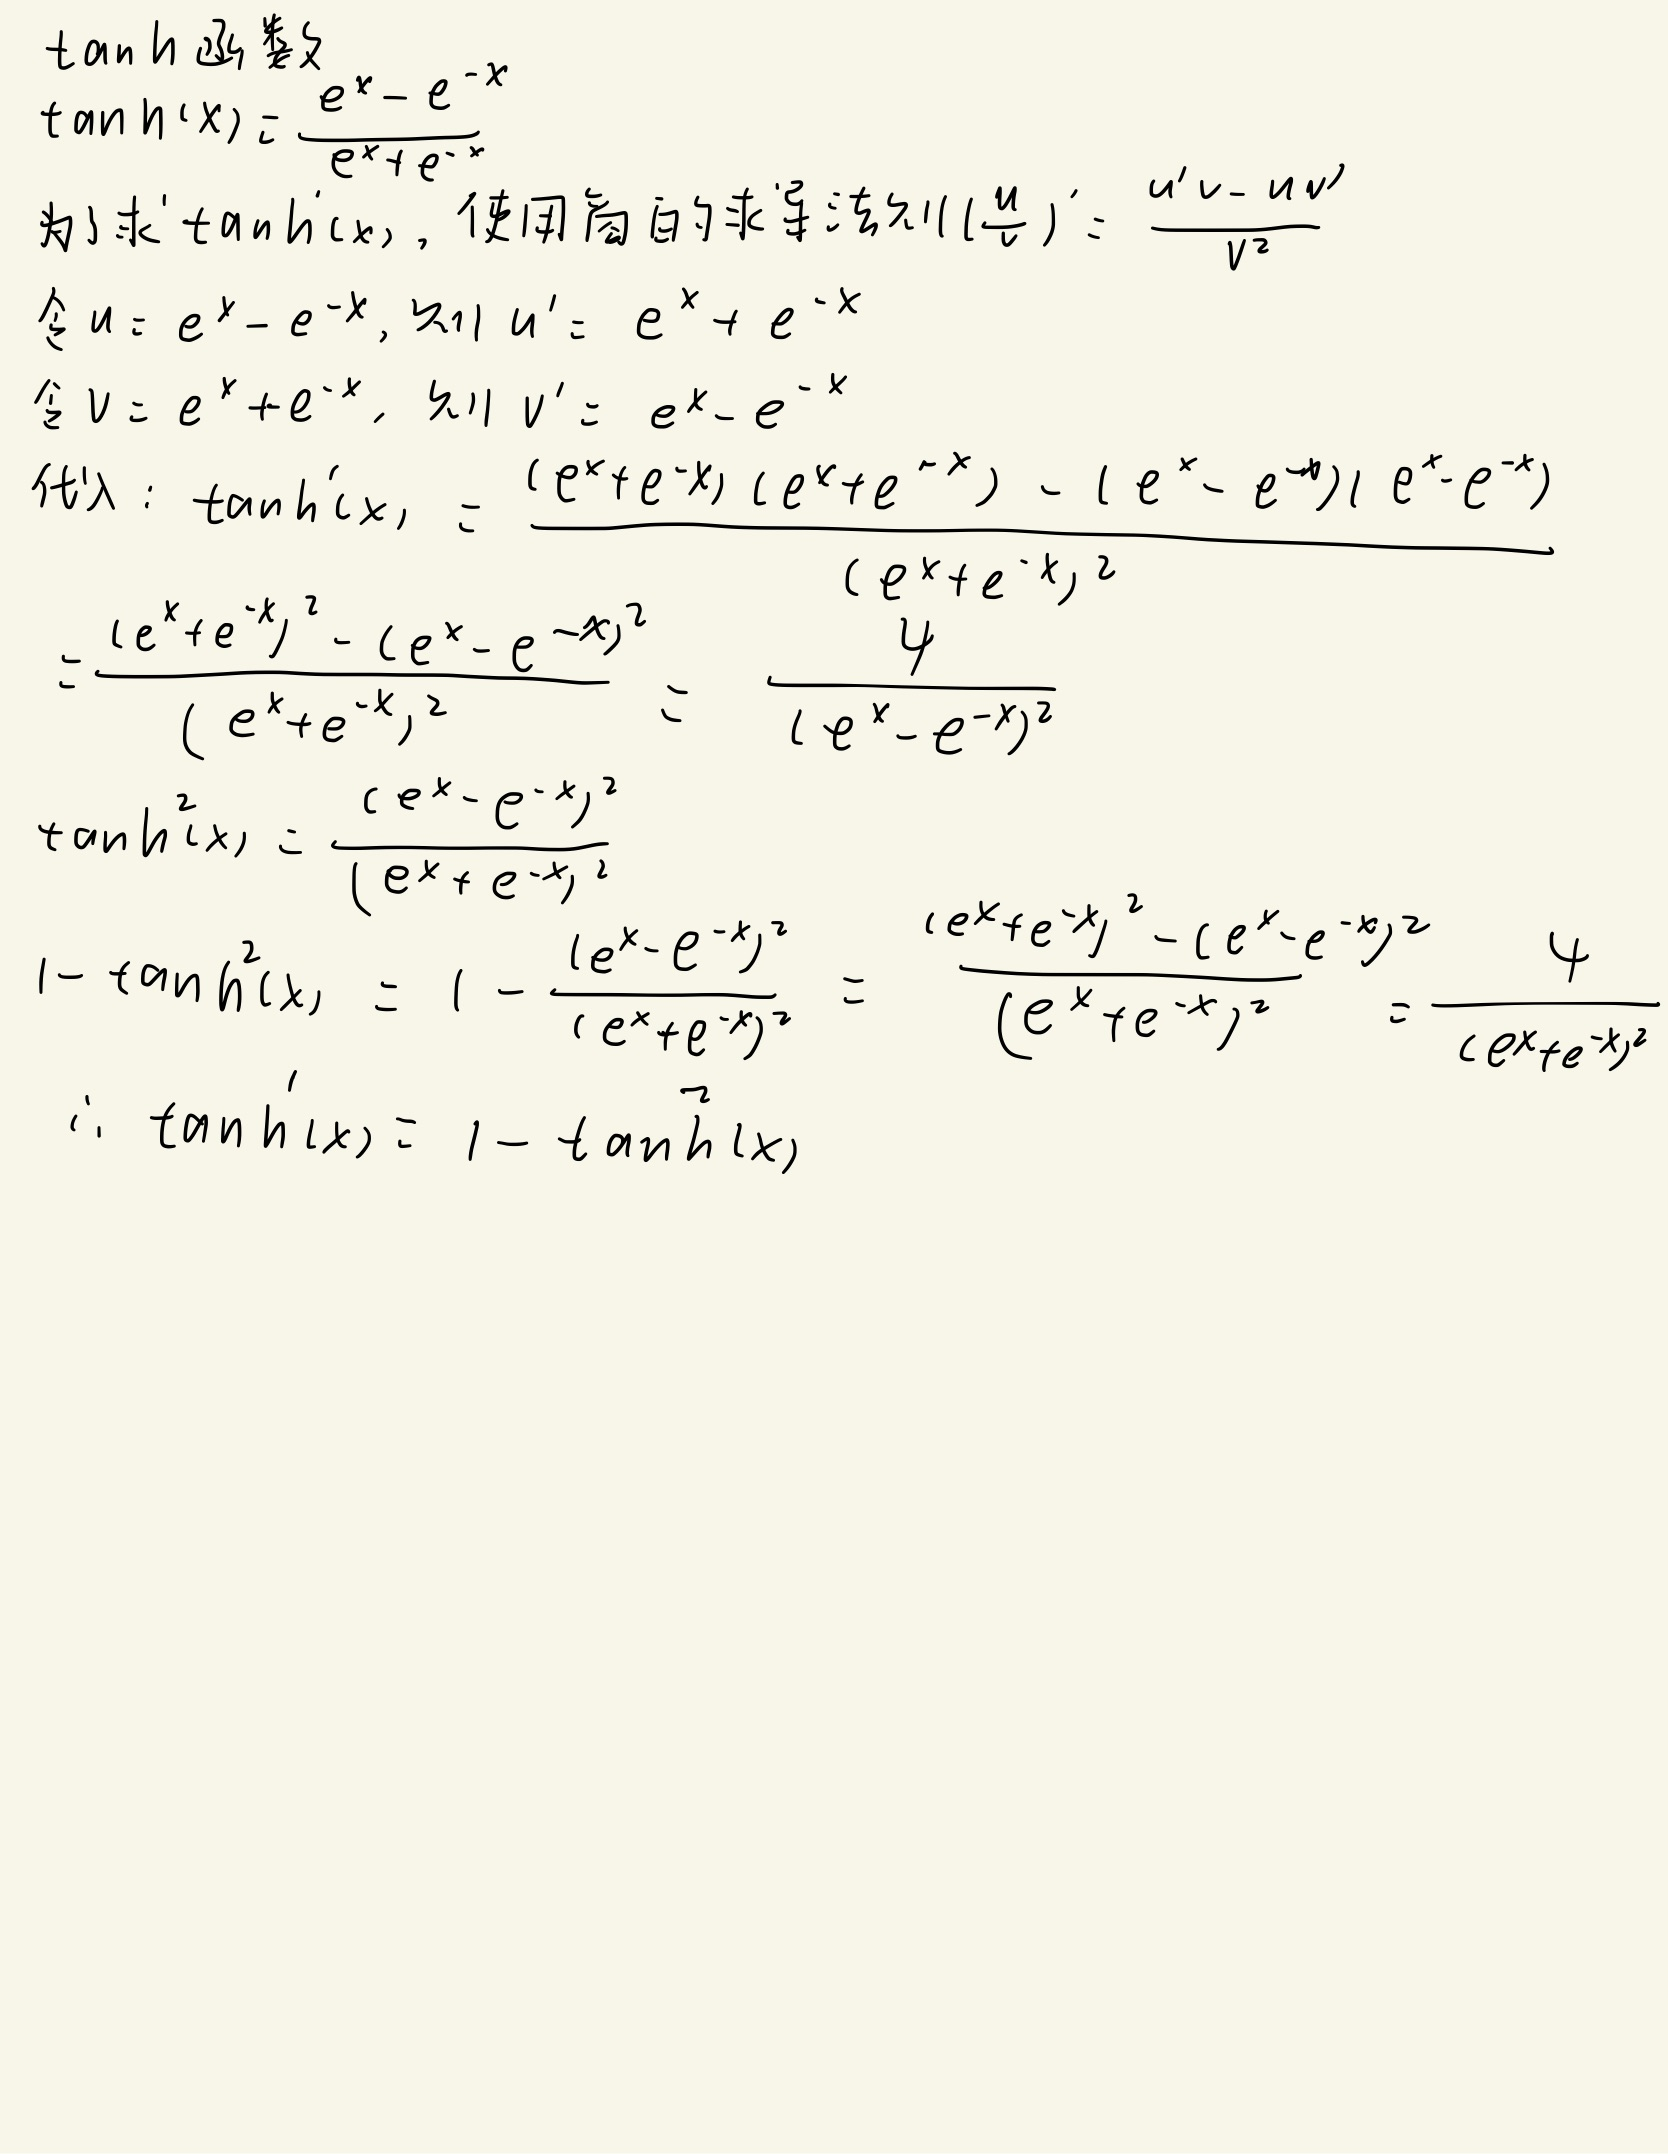

100%|██████████| 26.4M/26.4M [00:05<00:00, 4.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 89.8kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.45MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.46MB/s]


Epoch  1, Loss: 1.0444, Test Acc: 0.7244
Epoch  2, Loss: 0.5976, Test Acc: 0.8106
Epoch  3, Loss: 0.5237, Test Acc: 0.8118
Epoch  4, Loss: 0.4833, Test Acc: 0.8267
Epoch  5, Loss: 0.4549, Test Acc: 0.7972
Epoch  6, Loss: 0.4362, Test Acc: 0.8266
Epoch  7, Loss: 0.4169, Test Acc: 0.8360
Epoch  8, Loss: 0.4075, Test Acc: 0.8356
Epoch  9, Loss: 0.3930, Test Acc: 0.8483
Epoch 10, Loss: 0.3845, Test Acc: 0.8353


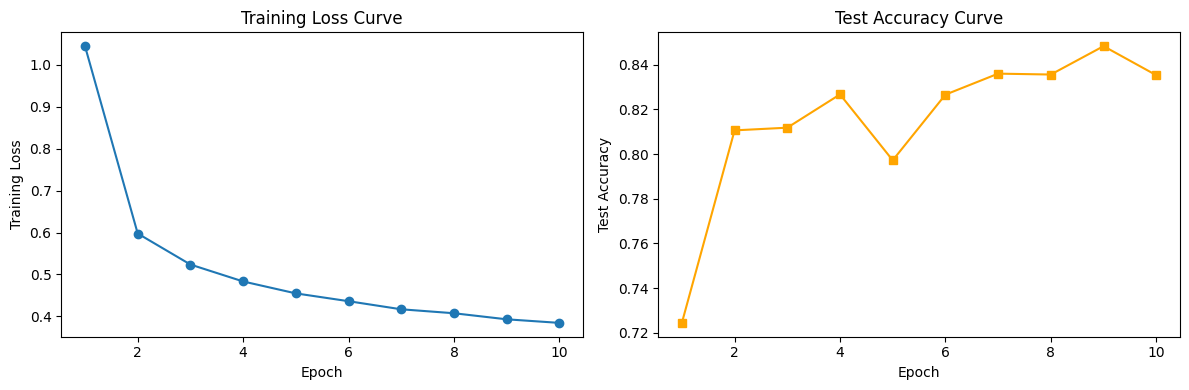

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)

# 加载Fashion-MNIST数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 参数初始化
input_size = 28*28
hidden_size = 256
output_size = 10

# 正态分布初始化 (均值为0, 标准差0.01)
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 启用梯度
W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

# ReLU激活函数
def relu(x):
    return torch.max(x, torch.tensor(0.0))

# Softmax + 交叉熵损失
def softmax_cross_entropy(logits, labels):
    # logits: (batch_size, num_classes), labels: (batch_size,)
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])  # 数值稳定
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(labels)), labels] + 1e-8).mean()
    return loss

# 训练超参数
lr = 0.1
epochs = 10

train_losses = []
test_accs = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for X, y in train_loader:
        # 前向传播
        h = torch.mm(X, W1) + b1
        h_relu = relu(h)
        logits = torch.mm(h_relu, W2) + b2
        loss = softmax_cross_entropy(logits, y)
        
        # 反向传播 (手动计算梯度)
        loss.backward()
        
        # SGD更新
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            # 梯度清零
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            h = relu(torch.mm(X, W1) + b1)
            logits = torch.mm(h, W2) + b2
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    acc = correct / total
    test_accs.append(acc)
    print(f"Epoch {epoch+1:2d}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

# 绘制曲线
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), test_accs, marker='s', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Curve')
plt.tight_layout()
plt.show()

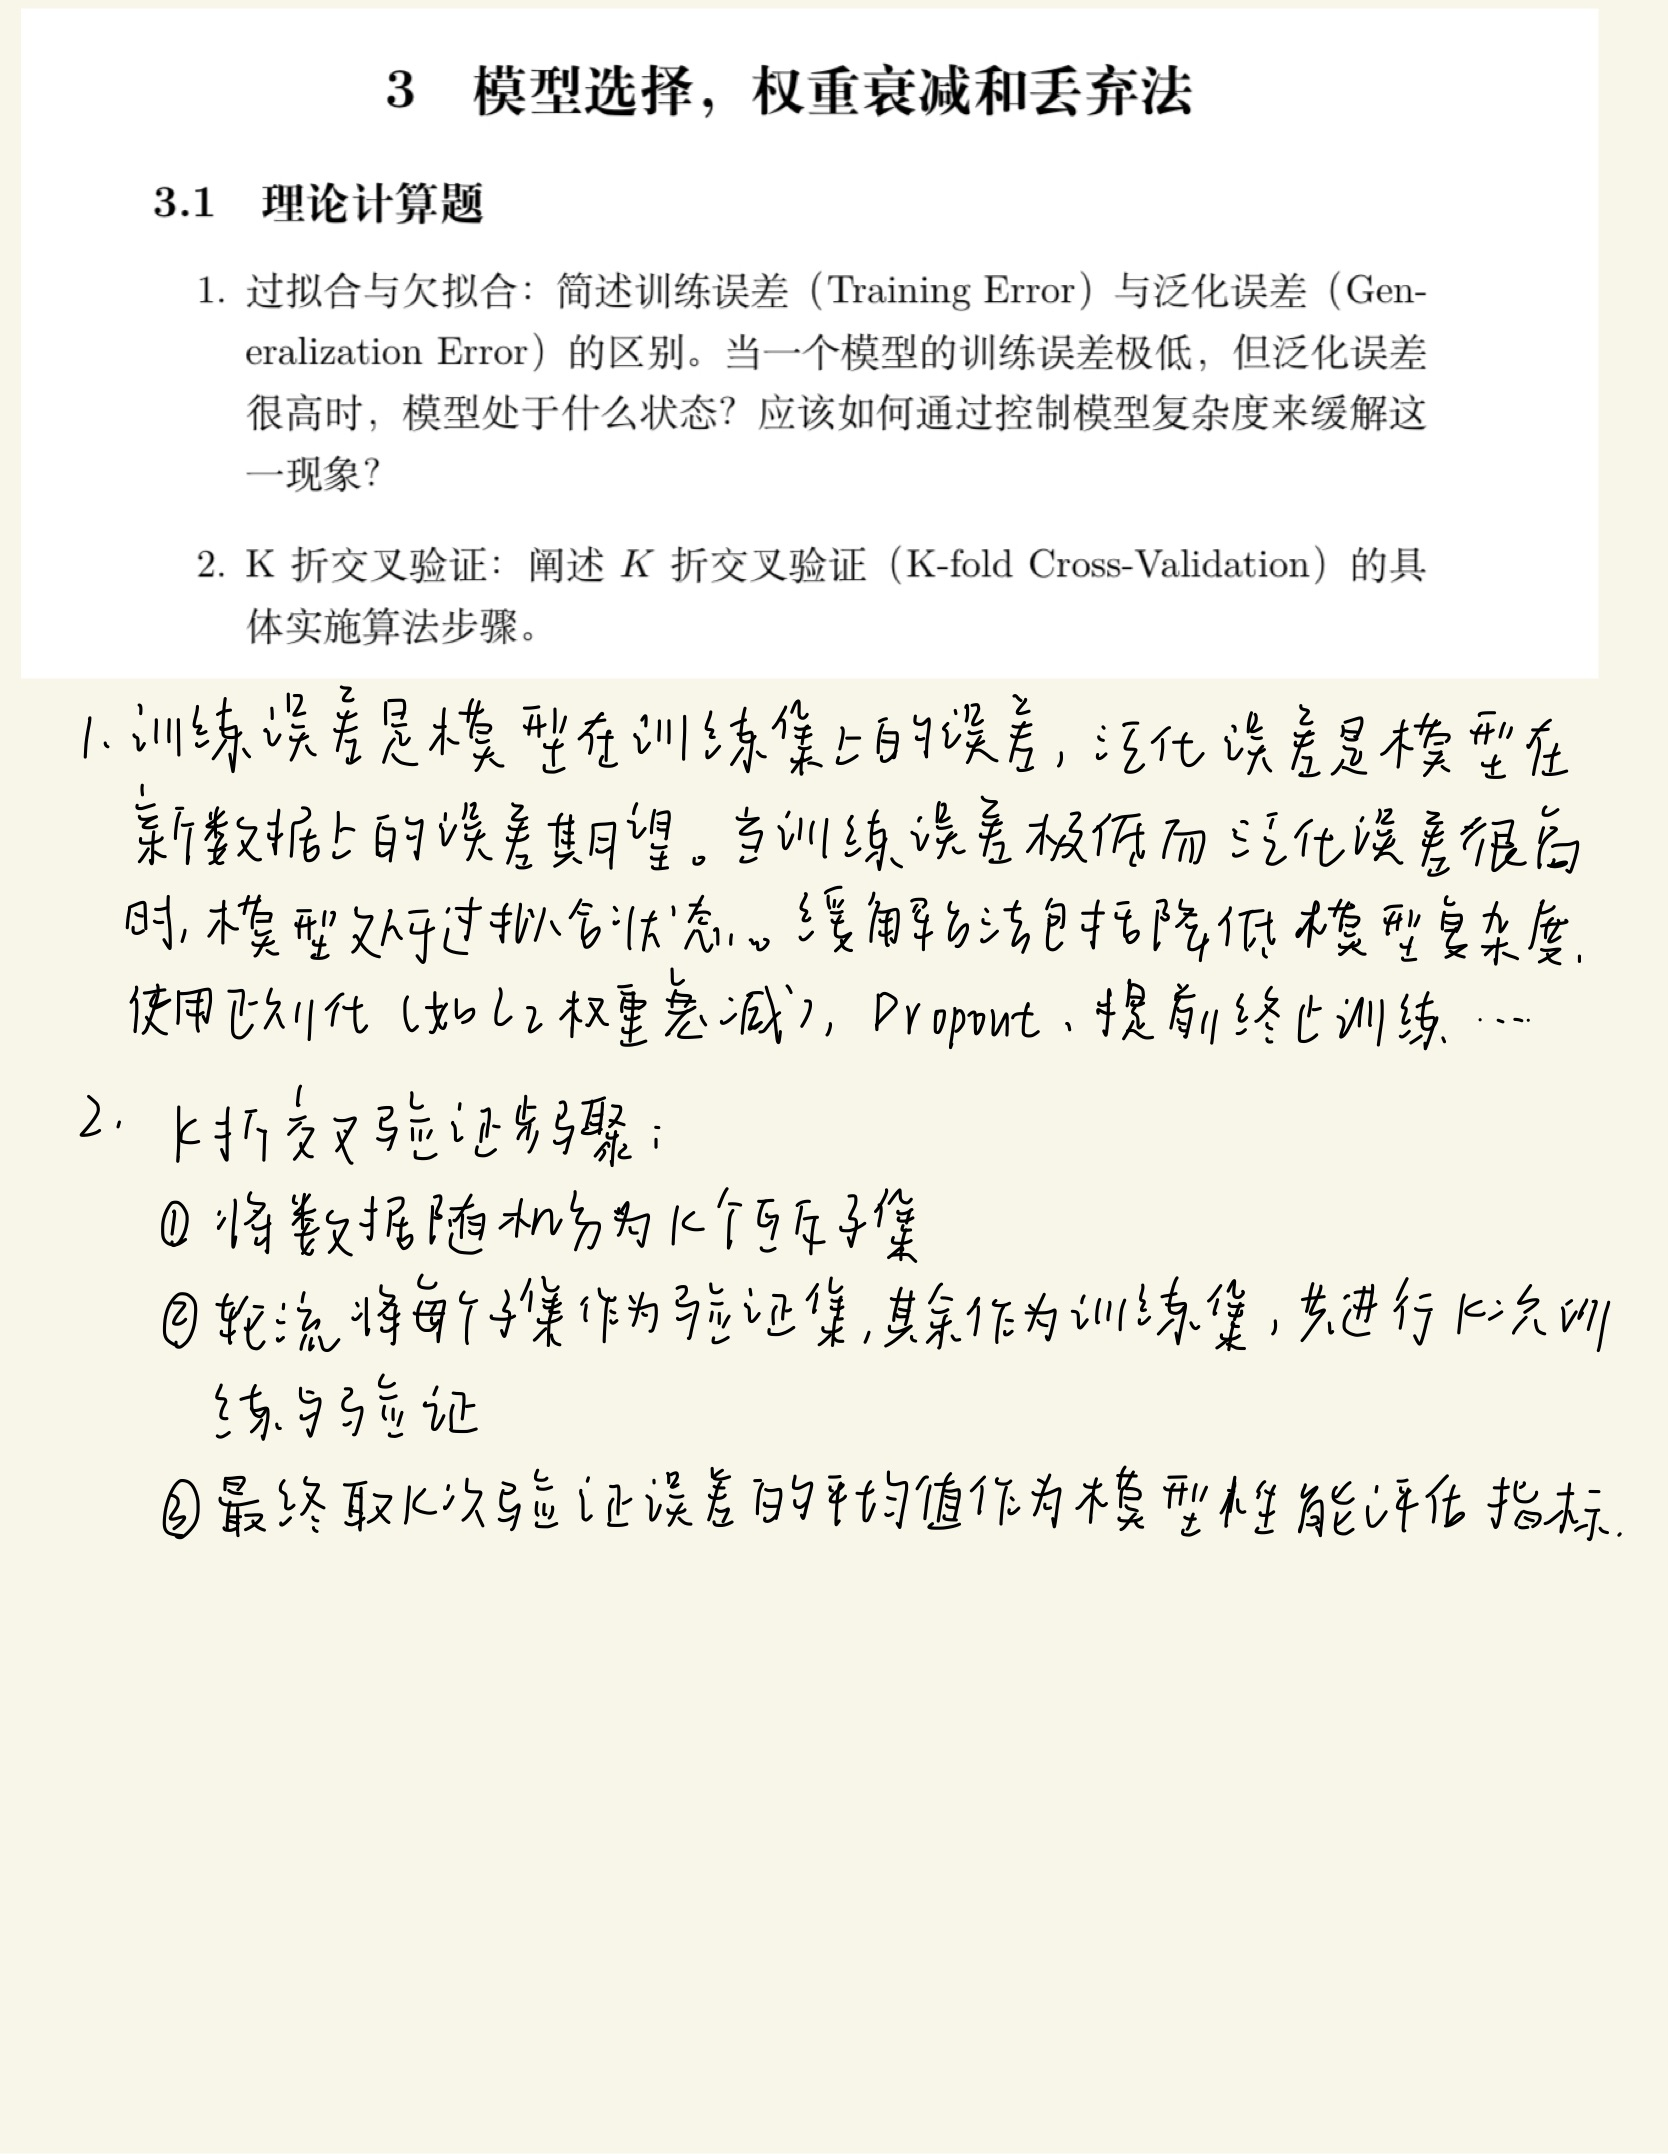

Epoch  5, Train Loss: 1.0124, Val Loss: 1.0162
Epoch 10, Train Loss: 0.7268, Val Loss: 0.7624
Epoch 15, Train Loss: 0.6132, Val Loss: 0.6742
Epoch 20, Train Loss: 0.5024, Val Loss: 0.6512
Epoch 25, Train Loss: 0.4181, Val Loss: 0.6209
Epoch 30, Train Loss: 0.3941, Val Loss: 0.6078
Epoch  5, Train Loss: 1.2883, Val Loss: 1.0360
Epoch 10, Train Loss: 1.0304, Val Loss: 0.9345
Epoch 15, Train Loss: 0.9253, Val Loss: 0.7799
Epoch 20, Train Loss: 0.8421, Val Loss: 0.7599
Epoch 25, Train Loss: 0.8144, Val Loss: 0.7682
Epoch 30, Train Loss: 0.7833, Val Loss: 0.7202
Epoch  5, Train Loss: 1.1229, Val Loss: 1.0328
Epoch 10, Train Loss: 0.8144, Val Loss: 0.8625
Epoch 15, Train Loss: 0.6759, Val Loss: 0.7018
Epoch 20, Train Loss: 0.5999, Val Loss: 0.6738
Epoch 25, Train Loss: 0.5198, Val Loss: 0.6152
Epoch 30, Train Loss: 0.4647, Val Loss: 0.6213


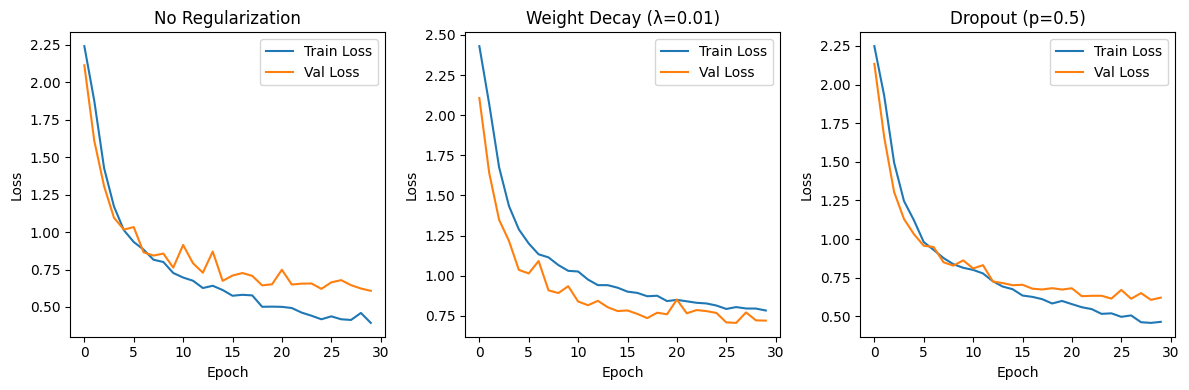

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)

# 加载数据（同上）
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 参数初始化
input_size = 28*28
hidden_size = 256
output_size = 10

def init_params():
    W1 = torch.randn(input_size, hidden_size) * 0.01
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn(hidden_size, output_size) * 0.01
    b2 = torch.zeros(output_size)
    W1.requires_grad_(True); b1.requires_grad_(True)
    W2.requires_grad_(True); b2.requires_grad_(True)
    return W1, b1, W2, b2

# Dropout实现
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return X * mask / (1.0 - dropout)

# Softmax交叉熵损失
def softmax_cross_entropy(logits, labels):
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(labels)), labels] + 1e-8).mean()
    return loss

# 训练函数（可选择weight_decay和dropout）
def train_model(weight_decay=0.0, dropout=0.0, epochs=20):
    W1, b1, W2, b2 = init_params()
    lr = 0.1
    train_losses = []
    val_losses = []
    
    # 为了模拟过拟合，只使用少量训练样本（如1000个）
    small_train_loader = torch.utils.data.DataLoader(
        torch.utils.data.Subset(train_dataset, list(range(1000))),
        batch_size=64, shuffle=True)
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        for X, y in small_train_loader:
            # 前向传播
            h = torch.mm(X, W1) + b1
            h_relu = torch.max(h, torch.tensor(0.0))
            # 应用Dropout（仅在训练时）
            h_drop = dropout_layer(h_relu, dropout, is_training=True)
            logits = torch.mm(h_drop, W2) + b2
            loss = softmax_cross_entropy(logits, y)
            
            # L2正则化（权重衰减）
            if weight_decay > 0:
                l2_penalty = weight_decay * (torch.sum(W1**2) + torch.sum(W2**2))
                loss = loss + l2_penalty
            
            loss.backward()
            
            # 带权重衰减的SGD更新 (w = w - lr*(grad + weight_decay*w))
            with torch.no_grad():
                W1 -= lr * (W1.grad + weight_decay * W1)
                b1 -= lr * b1.grad
                W2 -= lr * (W2.grad + weight_decay * W2)
                b2 -= lr * b2.grad
                W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(small_train_loader)
        train_losses.append(avg_train_loss)
        
        # 验证集（全部测试集）
        val_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                h = torch.mm(X, W1) + b1
                h_relu = torch.max(h, torch.tensor(0.0))
                logits = torch.mm(h_relu, W2) + b2
                loss = softmax_cross_entropy(logits, y)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses

# 对比实验
configs = [
    ("No Regularization", 0.0, 0.0),
    ("Weight Decay (λ=0.01)", 0.01, 0.0),
    ("Dropout (p=0.5)", 0.0, 0.5)
]

plt.figure(figsize=(12, 4))
for i, (name, wd, dp) in enumerate(configs):
    train_loss, val_loss = train_model(weight_decay=wd, dropout=dp, epochs=30)
    plt.subplot(1, 3, i+1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

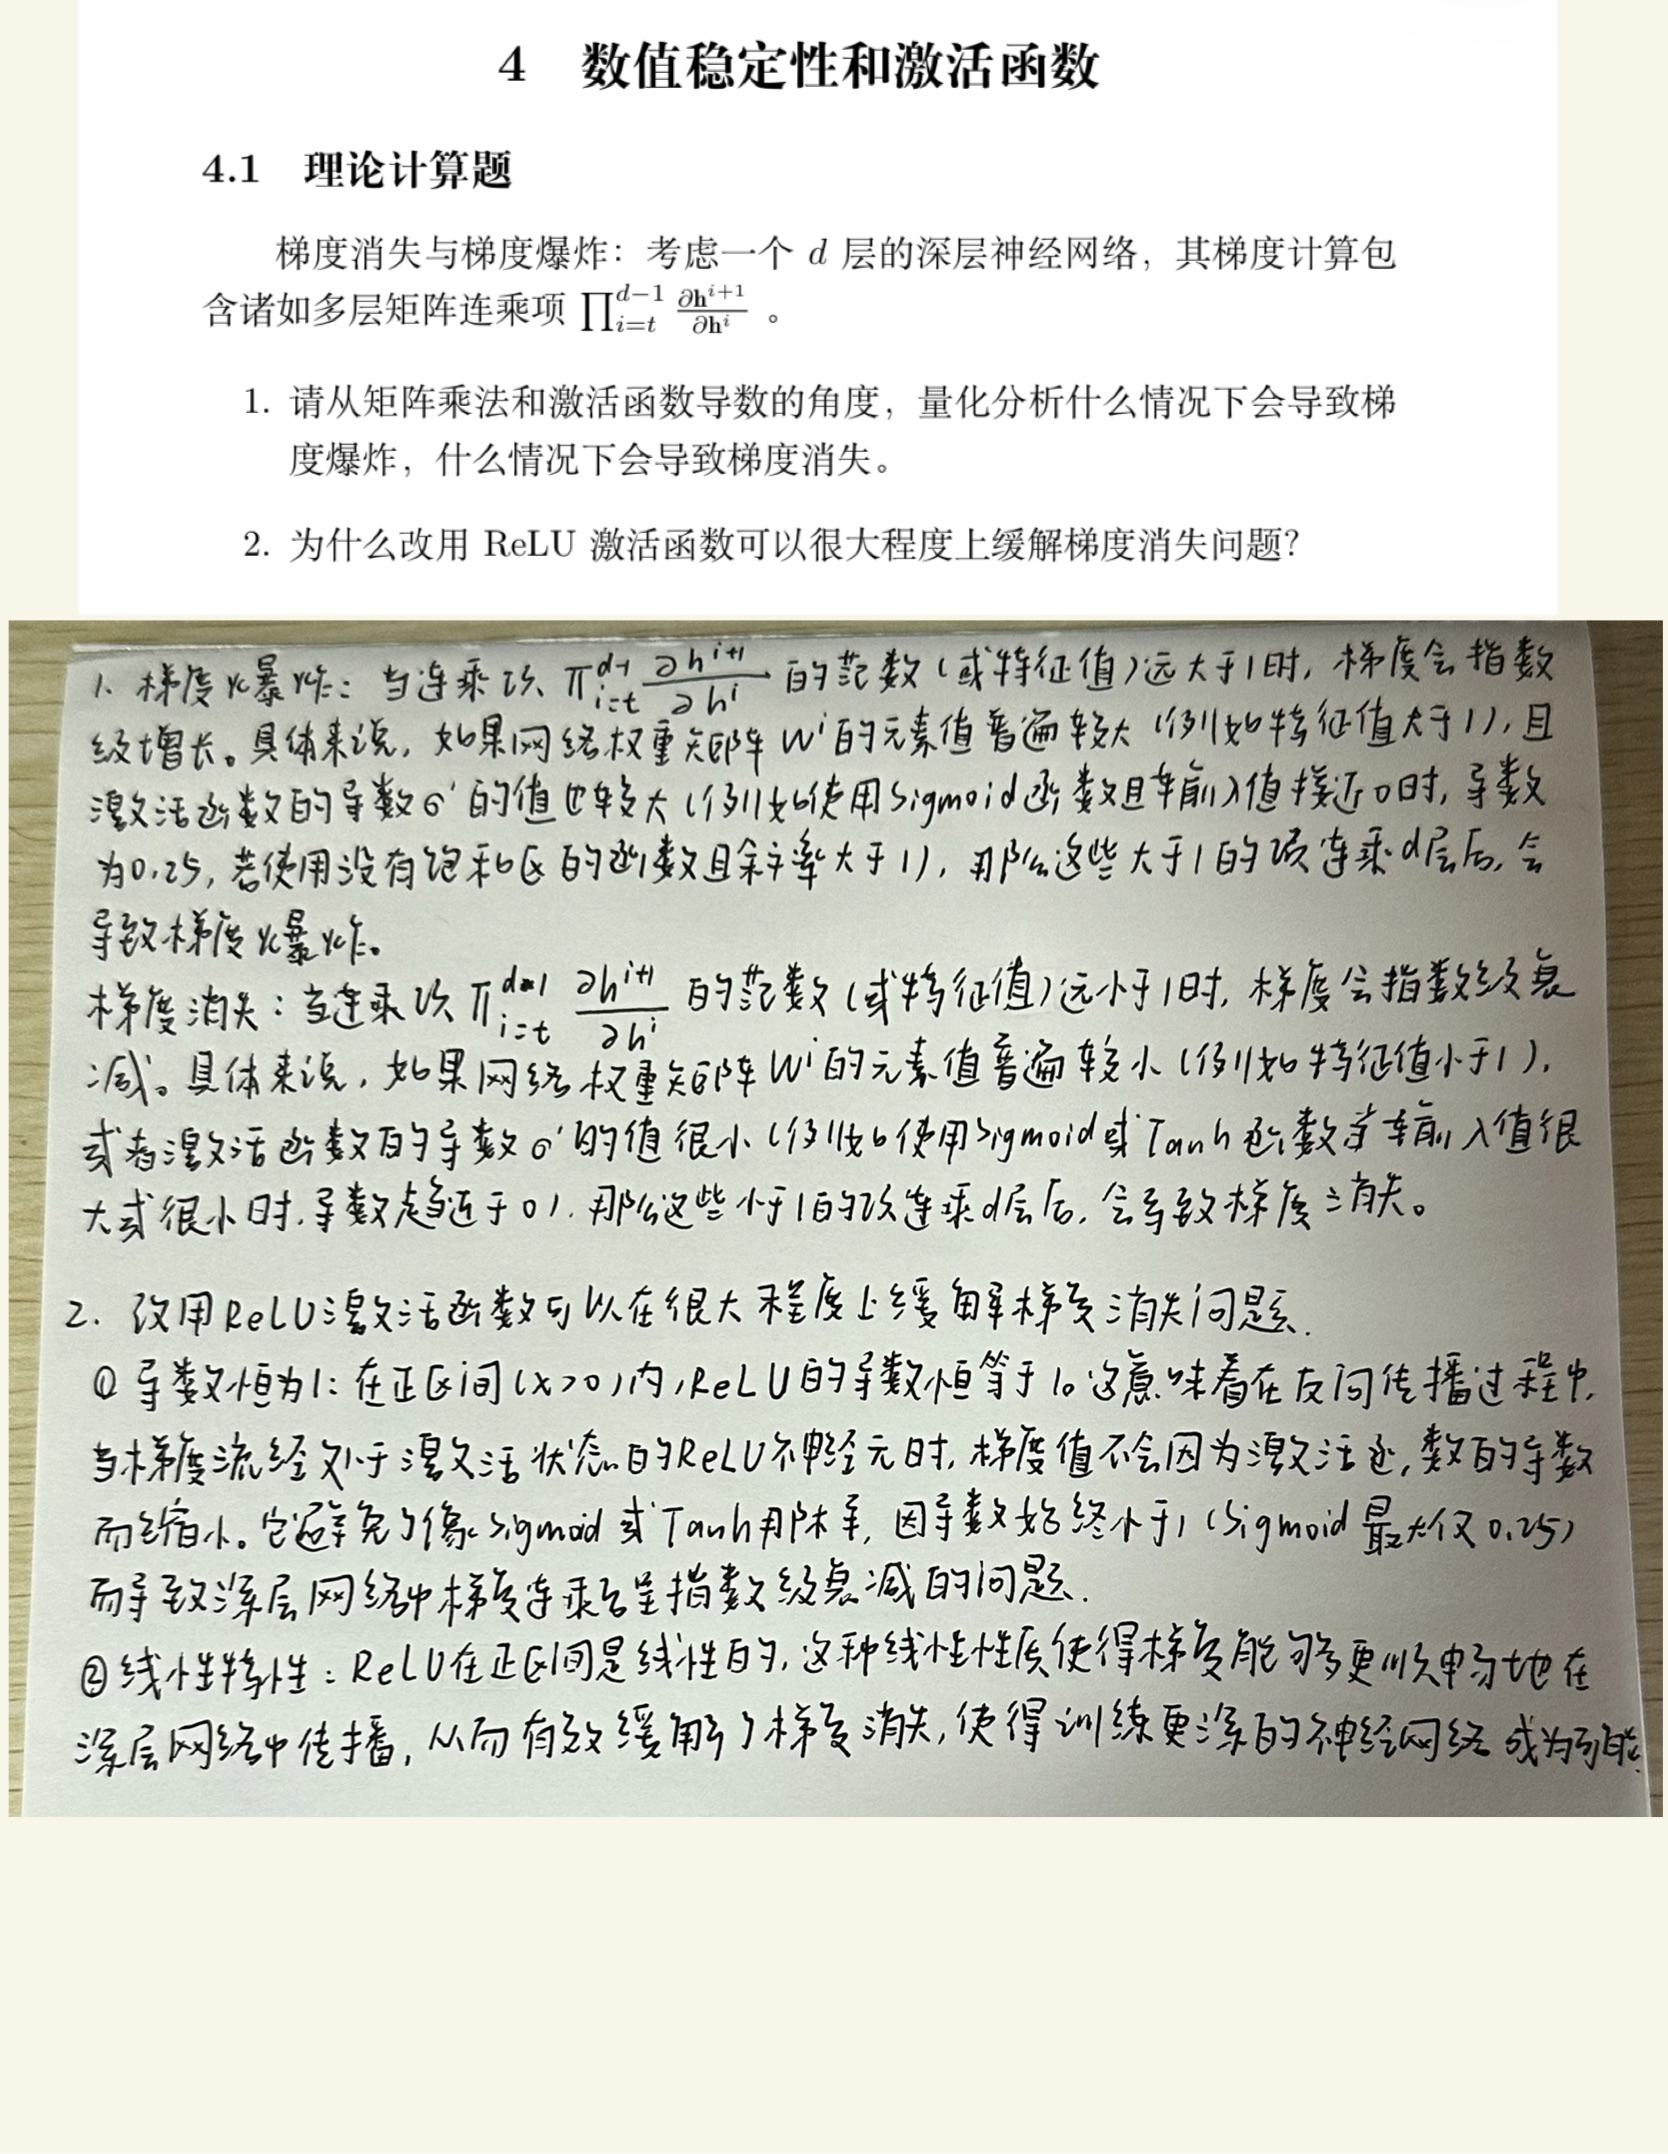

Sigmoid + Normal(std=1) 各层梯度范数（前5层 vs 后5层）:
前5层: [7427.94580078125, 5527.81689453125, 3922.843994140625, 3465.390625, 2661.991943359375]
后5层: [391.3758544921875, 457.29815673828125, 441.7958679199219, 490.66162109375, 567.91357421875]

ReLU + Normal(std=10) 是否产生NaN: True

Xavier + ReLU 各层梯度范数（前5层 vs 后5层）:
前5层: [5.047185897827148, 9.077738761901855, 11.524600982666016, 12.641488075256348, 14.330632209777832]
后5层: [18.86831283569336, 18.6472110748291, 15.370927810668945, 13.972177505493164, 10.862643241882324]


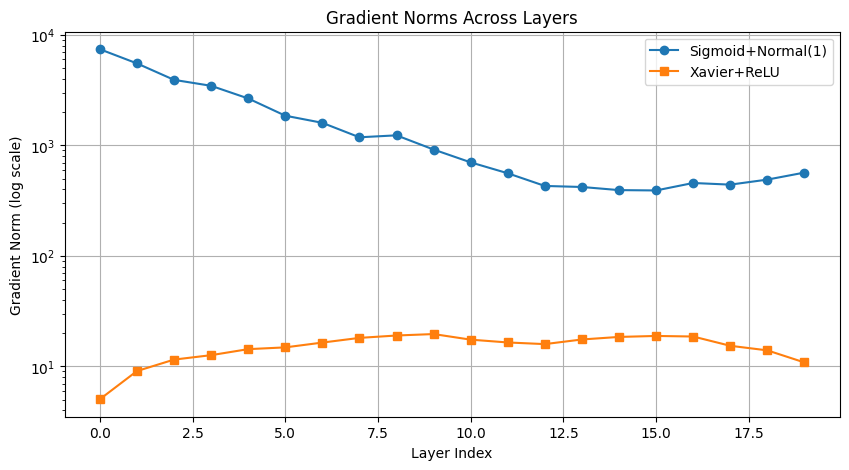

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 构建20层深层全连接网络
class DeepNet(nn.Module):
    def __init__(self, activation='sigmoid', init_method='normal', std=1.0):
        super().__init__()
        layers = []
        for i in range(20):
            layers.append(nn.Linear(256, 256))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.01))
        self.net = nn.Sequential(*layers)
        
        # 初始化权重
        self.apply_init(init_method, std)
    
    def apply_init(self, method, std):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if method == 'normal':
                    nn.init.normal_(m.weight, mean=0, std=std)
                elif method == 'xavier_uniform':
                    nn.init.xavier_uniform_(m.weight)
                elif method == 'xavier_normal':
                    nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)

# 计算各层梯度范数
def compute_grad_norms(model, x):
    model.zero_grad()
    out = model(x)
    loss = out.sum()  # dummy loss
    loss.backward()
    norms = []
    for i, m in enumerate(model.modules()):
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                norms.append(m.weight.grad.norm().item())
    return norms

# 实验1: Sigmoid + 标准正态初始化 (梯度消失)
model1 = DeepNet(activation='sigmoid', init_method='normal', std=1.0)
x = torch.randn(64, 256)
norms1 = compute_grad_norms(model1, x)
print("Sigmoid + Normal(std=1) 各层梯度范数（前5层 vs 后5层）:")
print("前5层:", norms1[:5])
print("后5层:", norms1[-5:])

# 实验2: ReLU + 大初始值(std=10) (梯度爆炸/NaN)
model2 = DeepNet(activation='relu', init_method='normal', std=10.0)
try:
    out = model2(x)
    loss = out.sum()
    loss.backward()
    has_nan = any(torch.isnan(p.grad).any() for p in model2.parameters() if p.grad is not None)
    print(f"\nReLU + Normal(std=10) 是否产生NaN: {has_nan}")
except Exception as e:
    print(f"\nReLU + Normal(std=10) 出现异常: {e}")

# 实验3: Xavier初始化 + ReLU (梯度稳定)
model3 = DeepNet(activation='relu', init_method='xavier_uniform', std=None)
norms3 = compute_grad_norms(model3, x)
print("\nXavier + ReLU 各层梯度范数（前5层 vs 后5层）:")
print("前5层:", norms3[:5])
print("后5层:", norms3[-5:])

# 绘制梯度分布对比
plt.figure(figsize=(10,5))
plt.plot(norms1, label='Sigmoid+Normal(1)', marker='o')
plt.plot(norms3, label='Xavier+ReLU', marker='s')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Norms Across Layers')
plt.legend()
plt.grid(True)
plt.show()

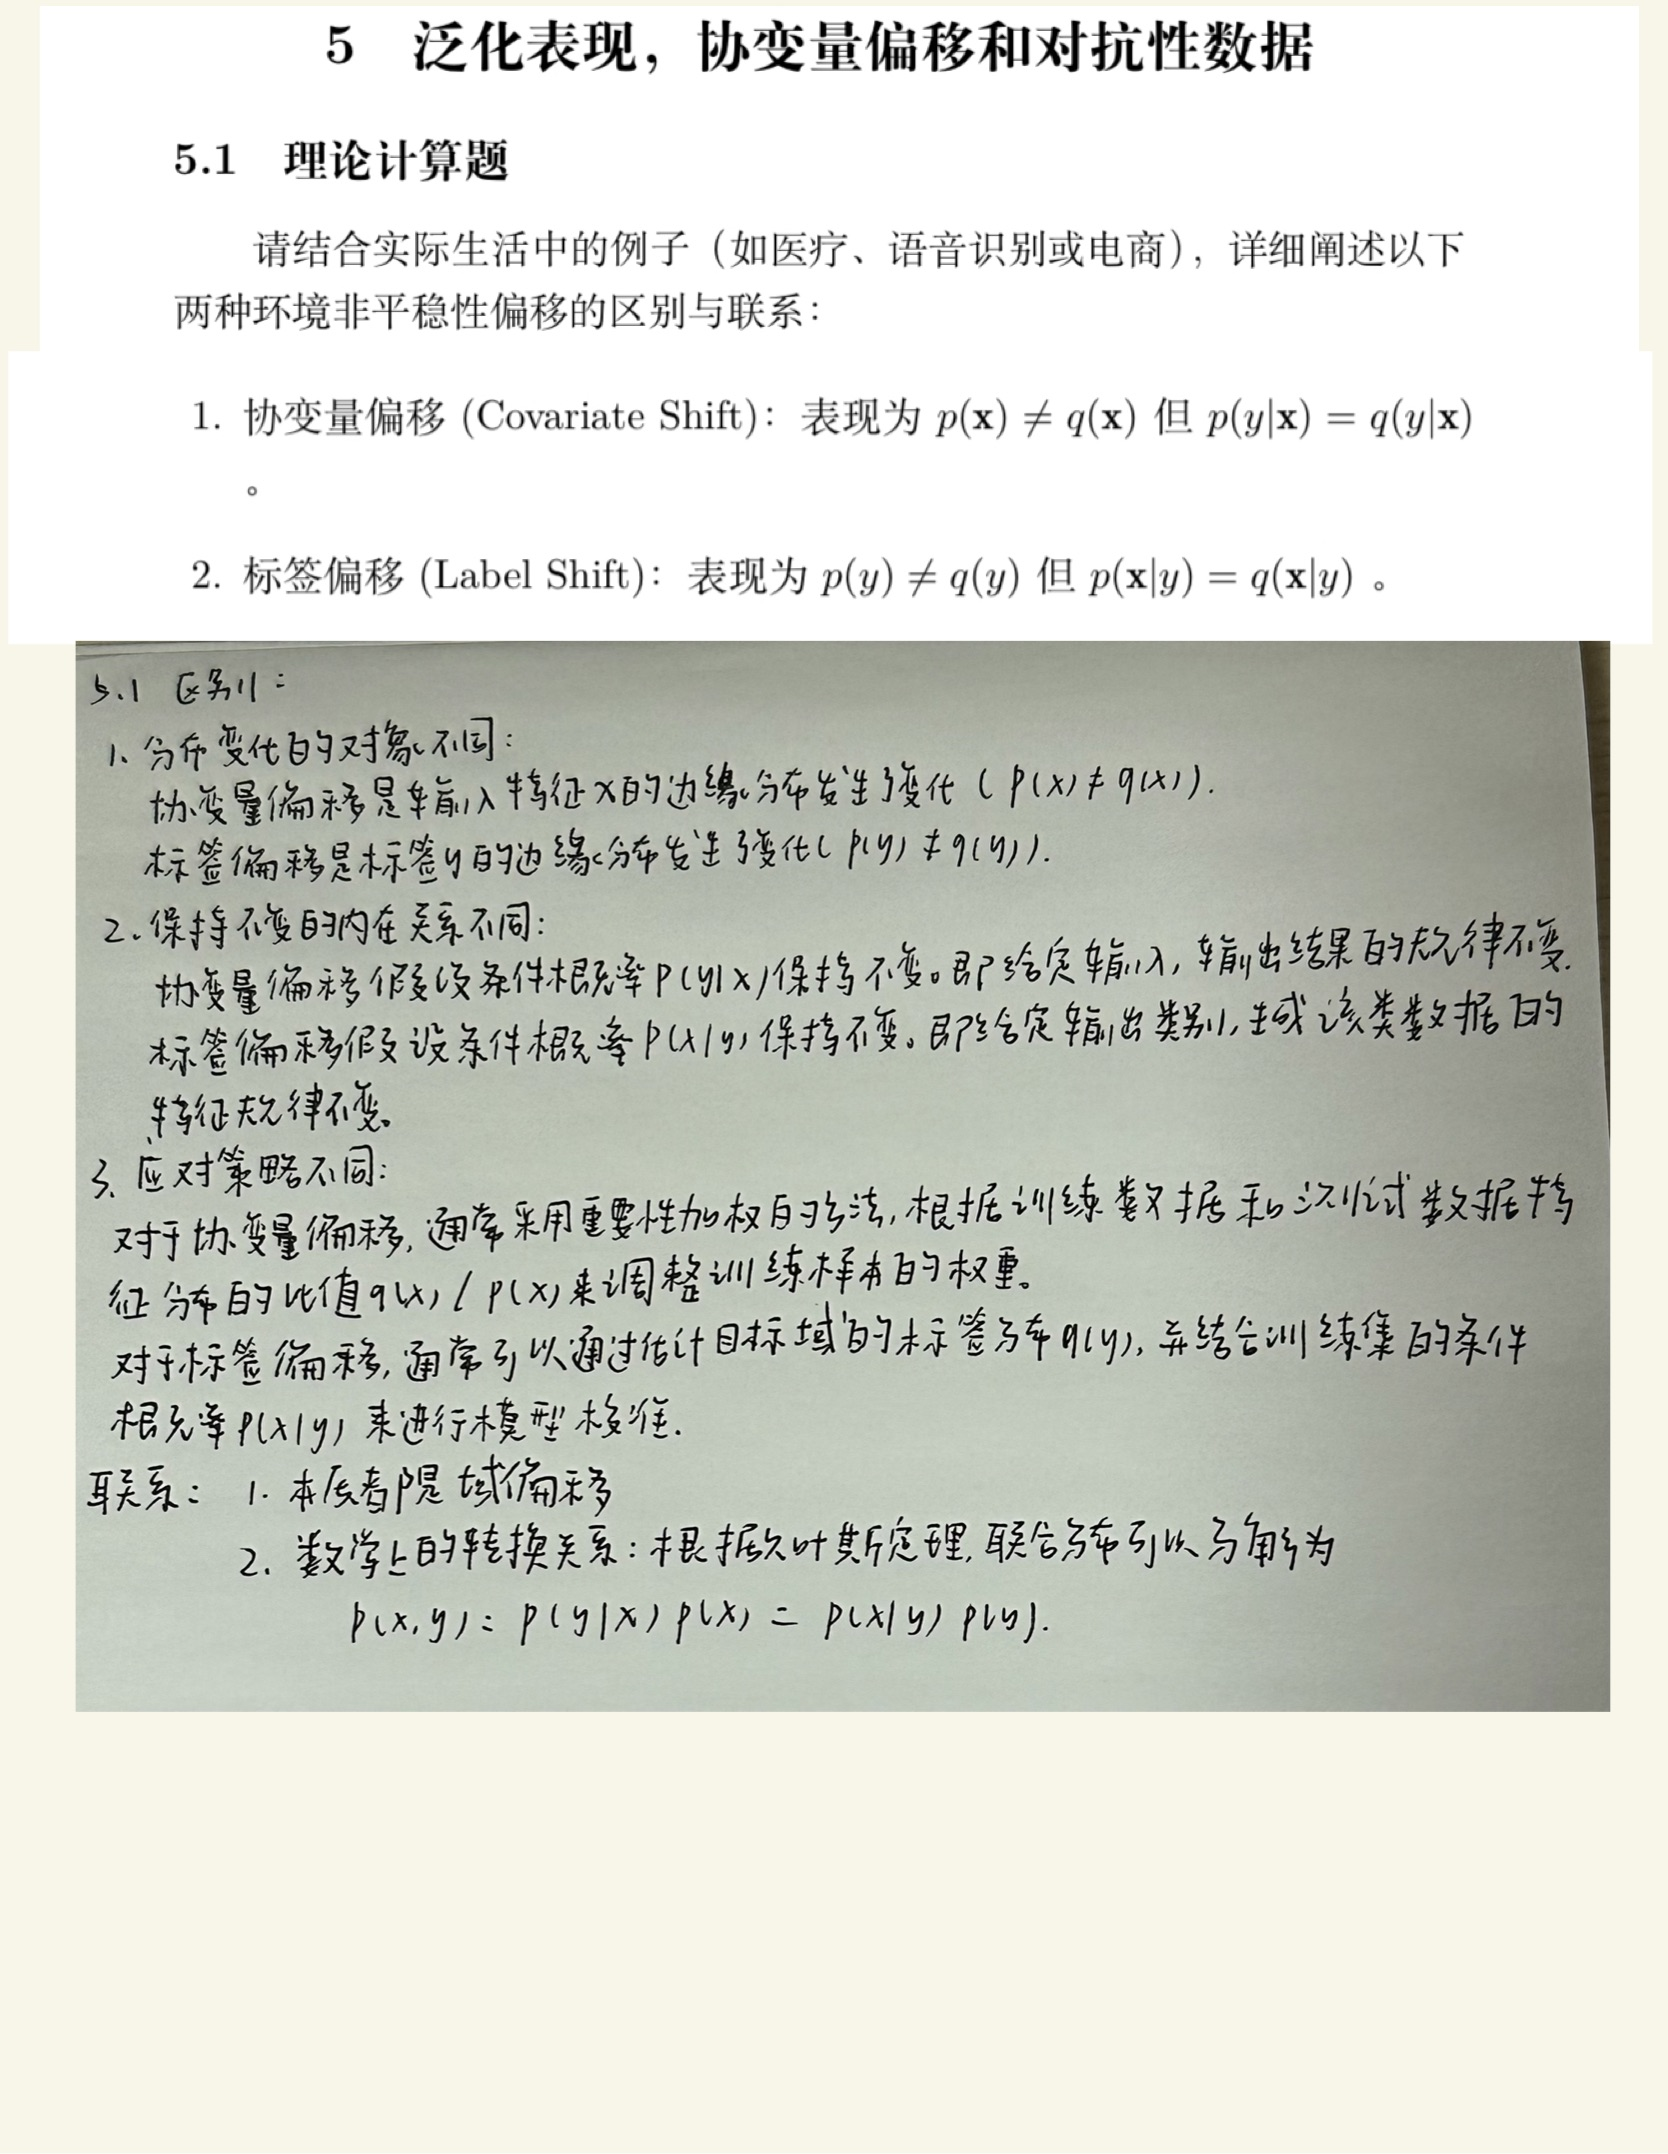

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error

# 1. 生成数据
np.random.seed(42)
n_train = 1000
n_test = 500

# 训练集: x ~ N(-1,1), y = 2x + eps
x_train = np.random.normal(-1, 1, n_train)
eps = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps

# 测试集: x ~ N(2,1), y = 2x + eps (关系相同)
x_test = np.random.normal(2, 1, n_test)
eps_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * x_test + eps_test

# 2. 基线模型：普通线性回归
model_baseline = LinearRegression()
model_baseline.fit(x_train.reshape(-1,1), y_train)
y_pred_baseline = model_baseline.predict(x_test.reshape(-1,1))
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f"基线模型 MSE: {mse_baseline:.4f}")

# 3. 训练逻辑回归分类器以估计权重
# 给训练集样本标记为0，测试集样本标记为1
X_combined = np.concatenate([x_train, x_test]).reshape(-1,1)
y_combined = np.concatenate([np.zeros(n_train), np.ones(n_test)])

# 注意：这里为了得到概率，通常需要更复杂的模型，但逻辑回归足以估计 P(test|x)
clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 预测每个样本属于测试集的概率
proba_test = clf.predict_proba(x_train.reshape(-1,1))[:, 1]  # P(test|x)
proba_train = 1 - proba_test  # P(train|x) = 1 - P(test|x) 因为只有两类

# 计算权重 w_i = P(test|x_i) / P(train|x_i)
# 为了避免除零，加小常数
weights = proba_test / (proba_train + 1e-8)

# 归一化权重（可选，不影响加权最小二乘的比例）
weights = weights / np.sum(weights) * len(weights)

# 4. 加权线性回归（加权最小二乘法）
# sklearn LinearRegression 不支持样本权重，手动实现或使用 statsmodels
# 这里手动实现加权最小二乘: beta = (X^T W X)^{-1} X^T W y
X_design = np.column_stack([np.ones_like(x_train), x_train])
W = np.diag(weights)
beta_hat = np.linalg.inv(X_design.T @ W @ X_design) @ (X_design.T @ W @ y_train)
y_pred_weighted = beta_hat[0] + beta_hat[1] * x_test
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权模型 MSE: {mse_weighted:.4f}")

print(f"\nMSE 改善: {mse_baseline - mse_weighted:.4f} ({(1 - mse_weighted/mse_baseline)*100:.2f}%)")

基线模型 MSE: 0.0102
加权模型 MSE: 0.0240

MSE 改善: -0.0138 (-135.90%)
